# 01. Vanilla Differences-in-Differences for a Marketing Campaign

This notebook is a self-contained introduction to simple Differences-in-Differences (DiD) using simulated marketing data.

We study a clean case where vanilla DiD is appropriate:
- A retailer turns on a new paid social campaign in a set of pilot markets starting in week 6.
- Matched holdout markets remain untreated throughout the sample.
- The outcome is weekly online orders per market.

The notebook is built to show the full logic of the design: define the shock, state the identification assumptions, assess comparability and pre-trends, visualize trajectories, and estimate the treatment effect with DiD.

## Learning Goals

By the end of this notebook, you should be able to:
- Clearly define the treatment, control, pre period, post period, and source of the shock.
- State the identification assumptions behind vanilla DiD.
- Check whether treated and untreated markets look similar before treatment.
- Assess whether the parallel-trends assumption looks plausible in the pre period.
- Estimate the treatment effect manually and with a DiD regression.
- Cluster the standard errors at the treatment-unit level to account for within-unit correlation over time.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter
import statsmodels.formula.api as smf

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")
rng = np.random.default_rng(42)

## Marketing Setup And Source Of The Shock

The causal shock in this example is the **discrete launch of a new paid social campaign in week 6 in pilot markets only**.

A concrete marketing story is:
- The retailer signs off on a geo-limited rollout of new creative, bidding rules, and audience targeting.
- The media team turns on spend in 6 pilot markets at the start of week 6.
- The 6 holdout markets remain dark during the entire 10-week window.
- The rollout date is fixed in advance rather than chosen in response to a demand spike in a specific market.

That switch-on at week 6 is the shock. In the simulation below, that shock adds incremental orders only to treated markets in the post period.

In [2]:
n_pairs = 6
n_weeks = 10
launch_week = 6
true_campaign_effect = 18

market_rows = []
for pair_id in range(1, n_pairs + 1):
    pair_population = rng.normal(100, 10)
    pair_income = rng.normal(105, 6)
    pair_conversion = rng.normal(0.035, 0.003)
    for treated in [1, 0]:
        market_rows.append(
            {
                "pair_id": pair_id,
                "market_id": f"M{len(market_rows) + 1:02d}",
                "treated": treated,
                "population_index": pair_population + rng.normal(0, 3),
                "income_index": pair_income + rng.normal(0, 2),
                "prior_conversion_rate": pair_conversion + rng.normal(0, 0.0015),
            }
        )

markets = pd.DataFrame(market_rows)
markets["prior_conversion_rate"] = markets["prior_conversion_rate"].clip(lower=0.020, upper=0.050)
markets["group"] = np.where(markets["treated"] == 1, "Pilot markets", "Holdout markets")
markets["baseline_orders"] = (
    65
    + 0.85 * markets["population_index"]
    + 0.55 * markets["income_index"]
    + 1300 * markets["prior_conversion_rate"]
)
markets["market_intercept"] = rng.normal(0, 5, size=len(markets))

weeks = pd.DataFrame({"week": np.arange(1, n_weeks + 1)})
weeks["post"] = (weeks["week"] >= launch_week).astype(int)
weeks["common_trend"] = np.array([-7, -4, -2, 1, 3, 5, 7, 9, 10, 12])
weeks["seasonality"] = np.array([-4, -2, -1, 0, 2, 3, 4, 5, 7, 6])

df = markets.assign(key=1).merge(weeks.assign(key=1), on="key").drop(columns="key")
df["campaign_shock"] = true_campaign_effect * df["treated"] * df["post"]
df["orders"] = (
    df["baseline_orders"]
    + df["market_intercept"]
    + df["common_trend"]
    + df["seasonality"]
    + df["campaign_shock"]
    + rng.normal(0, 6, size=len(df))
).round(2)

df.head()

,pair_id,market_id,treated,population_index,income_index,prior_conversion_rate,group,baseline_orders,market_intercept,week,post,common_trend,seasonality,campaign_shock,orders
0,1,M01,1,105.869,94.858,0.035,Pilot markets,253.048,-2.352,1,0,-7,-4,0,237.600
1,1,M01,1,105.869,94.858,0.035,Pilot markets,253.048,-2.352,2,0,-4,-2,0,241.920
2,1,M01,1,105.869,94.858,0.035,Pilot markets,253.048,-2.352,3,0,-2,-1,0,252.840
3,1,M01,1,105.869,94.858,0.035,Pilot markets,253.048,-2.352,4,0,1,0,0,250.550
4,1,M01,1,105.869,94.858,0.035,Pilot markets,253.048,-2.352,5,0,3,2,0,248.040


## Market-Level Setup

Treatment is assigned at the **market** level. Each market is observed repeatedly over time, so this is a short panel.

In [3]:
markets[[
    "market_id",
    "pair_id",
    "group",
    "population_index",
    "income_index",
    "prior_conversion_rate",
]].round(3)

,market_id,pair_id,group,population_index,income_index,prior_conversion_rate
0,M01,1,Pilot markets,105.869,94.858,0.035
1,M02,1,Holdout markets,103.431,98.128,0.037
2,M03,2,Pilot markets,91.668,112.531,0.038
3,M04,2,Holdout markets,88.892,111.014,0.036
4,M05,3,Pilot markets,106.742,107.146,0.034
5,M06,3,Holdout markets,107.500,103.996,0.035
6,M07,4,Pilot markets,110.079,106.664,0.036
7,M08,4,Holdout markets,101.213,108.708,0.038
8,M09,5,Pilot markets,100.812,101.446,0.033
9,M10,5,Holdout markets,96.864,100.423,0.033


## Identification Assumptions

For vanilla DiD to identify the causal effect of the campaign, we need the following assumptions:
- **Parallel trends:** absent the campaign, treated and holdout markets would have followed the same trend in orders over time.
- **No anticipation:** treated markets do not change behavior before week 6 because of the upcoming launch.
- **No spillovers:** the campaign in pilot markets does not affect orders in holdout markets.
- **Stable composition:** the set of markets and the way orders are measured do not change across periods.
- **No other treated-only shock at week 6:** nothing else starts in pilot markets at the same time as the campaign.

Some of these can be partially probed with the data. In particular, we can examine observable similarity and pre-treatment trends. But the post-period counterfactual itself is never directly observed, so the identifying assumption is ultimately a research design argument.

## 1. Are Treated And Untreated Markets Similar Before The Shock?

A first diagnostic is to compare pre-treatment observables and pre-period outcomes. Similarity on observables does not prove identification, but large imbalances would make the design less credible.

In [4]:
pre_period_market = (
    df[df["week"] < launch_week]
    .groupby("market_id", as_index=False)
    .agg(pre_period_orders=("orders", "mean"))
)

market_level = markets.merge(pre_period_market, on="market_id")

covariate_labels = {
    "population_index": "Population index",
    "income_index": "Income index",
    "prior_conversion_rate": "Prior conversion rate",
    "pre_period_orders": "Average pre-period orders",
}

balance_rows = []
for covariate, label in covariate_labels.items():
    treated_values = market_level.loc[market_level["treated"] == 1, covariate]
    control_values = market_level.loc[market_level["treated"] == 0, covariate]
    pooled_sd = np.sqrt((treated_values.var(ddof=1) + control_values.var(ddof=1)) / 2)
    balance_model = smf.ols(f"{covariate} ~ treated", data=market_level).fit(cov_type="HC1")
    balance_rows.append(
        {
            "variable": label,
            "treated_mean": treated_values.mean(),
            "control_mean": control_values.mean(),
            "difference": treated_values.mean() - control_values.mean(),
            "std_diff": (treated_values.mean() - control_values.mean()) / pooled_sd,
            "p_value": balance_model.pvalues["treated"],
        }
    )

balance_table = pd.DataFrame(balance_rows)
balance_table.round(3)

,variable,treated_mean,control_mean,difference,std_diff,p_value
0,Population index,103.232,100.330,2.902,0.445,0.441
1,Income index,105.501,104.931,0.571,0.099,0.864
2,Prior conversion rate,0.035,0.036,-0.000,-0.166,0.774
3,Average pre-period orders,251.415,255.212,-3.797,-0.511,0.376


If treated and holdout markets look similar on these baseline measures, that is supportive. But it is only a diagnostic: DiD still relies on the assumption that untreated trends would have moved in parallel after week 6.

## 2. Illustrate The Outcome Trajectory

Next, plot the path of orders over time. The figure below shows each market trajectory in the background and the average group trajectory in the foreground.

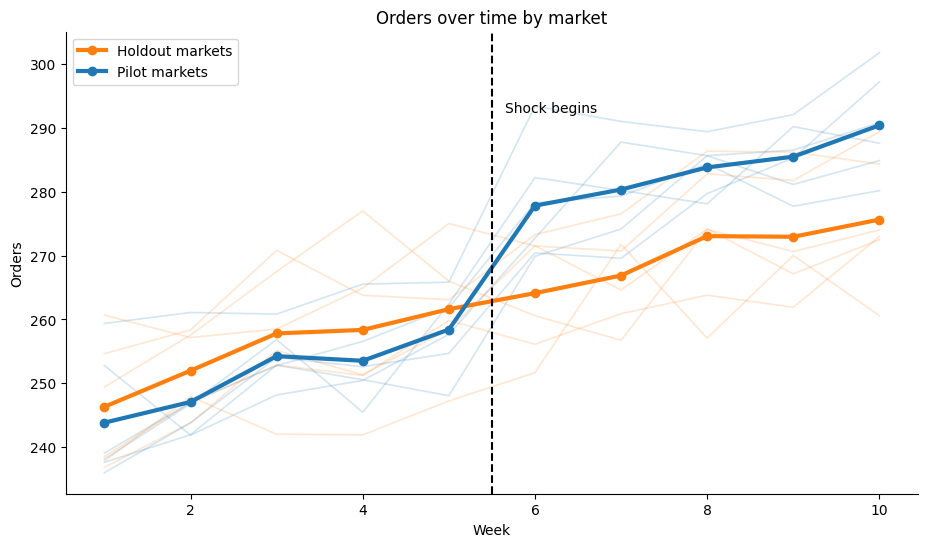

In [5]:
color_map = {"Pilot markets": "tab:blue", "Holdout markets": "tab:orange"}
weekly_means = df.groupby(["week", "group"], as_index=False)["orders"].mean()

fig, ax = plt.subplots(figsize=(11, 6))
for market_id, market_df in df.groupby("market_id"):
    group_name = market_df["group"].iat[0]
    ax.plot(
        market_df["week"],
        market_df["orders"],
        color=color_map[group_name],
        alpha=0.18,
        linewidth=1.25,
    )

for group_name, group_df in weekly_means.groupby("group"):
    ax.plot(
        group_df["week"],
        group_df["orders"],
        color=color_map[group_name],
        marker="o",
        linewidth=3,
        label=group_name,
    )

ax.axvline(launch_week - 0.5, color="black", linestyle="--", linewidth=1.5)
ax.text(launch_week - 0.35, weekly_means["orders"].max() + 2, "Shock begins", fontsize=10)
ax.set_title("Orders over time by market")
ax.set_xlabel("Week")
ax.set_ylabel("Orders")
ax.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
ax.legend(frameon=True)
plt.show()

## 3. Are Pre-Treatment Trends Parallel?

The key identifying assumption is about **untreated trends**. A standard check is to inspect the pre period only. If the treated and holdout groups move similarly before week 6, the DiD design becomes more credible.

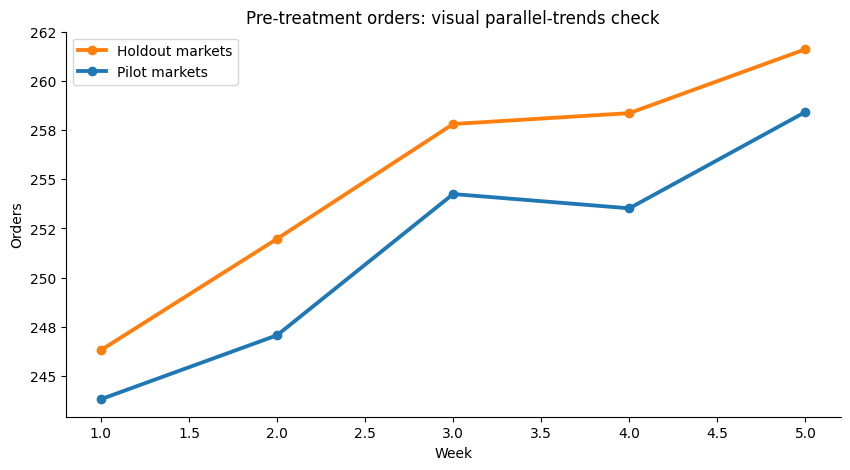

In [6]:
pre_weekly_means = weekly_means[weekly_means["week"] < launch_week]

fig, ax = plt.subplots()
for group_name, group_df in pre_weekly_means.groupby("group"):
    ax.plot(
        group_df["week"],
        group_df["orders"],
        color=color_map[group_name],
        marker="o",
        linewidth=2.75,
        label=group_name,
    )

ax.set_title("Pre-treatment orders: visual parallel-trends check")
ax.set_xlabel("Week")
ax.set_ylabel("Orders")
ax.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
ax.legend(frameon=True)
plt.show()

A visual check is useful, but it helps to add a simple regression test for differential pre-trends. In the pre period only, estimate:

\[
orders_{mt} = \alpha + \beta \cdot treated_m + \gamma \cdot week_t + \delta \cdot (treated_m \times week_t) + u_{mt}
\]

The coefficient of interest is \(\delta\). If it is close to zero, the data are consistent with parallel pre-trends. This is supportive evidence, not proof.

In [7]:
pre_period_df = df[df["week"] < launch_week].copy()
pretrend_model = smf.ols("orders ~ treated + week + treated:week", data=pre_period_df).fit(
    cov_type="cluster",
    cov_kwds={"groups": pre_period_df["market_id"]},
)

pretrend_results = pd.DataFrame({
    "coefficient": pretrend_model.params,
    "std_error": pretrend_model.bse,
    "p_value": pretrend_model.pvalues,
    "ci_low": pretrend_model.conf_int()[0],
    "ci_high": pretrend_model.conf_int()[1],
})

pretrend_results.loc[["treated:week"]].round(3)

,coefficient,std_error,p_value,ci_low,ci_high
treated:week,-0.133,0.917,0.885,-1.930,1.664


## 4. Apply DiD By Hand

The two-group, two-period DiD estimand is:

\[
(\bar{Y}_{\text{treated, post}} - \bar{Y}_{\text{treated, pre}}) - (\bar{Y}_{\text{control, post}} - \bar{Y}_{\text{control, pre}})
\]

This first takes differences within each group over time, then compares those group-level changes across treated and control markets.

In [8]:
mean_table = (
    df.groupby(["group", "post"], as_index=False)["orders"]
    .mean()
    .assign(period=lambda data: np.where(data["post"] == 1, "Post", "Pre"))
    .pivot(index="group", columns="period", values="orders")
)
mean_table["Change"] = mean_table["Post"] - mean_table["Pre"]
manual_did = mean_table.loc["Pilot markets", "Change"] - mean_table.loc["Holdout markets", "Change"]

mean_table.round(3)

period,Post,Pre,Change
group,,,
Holdout markets,270.541,255.212,15.329
Pilot markets,283.603,251.415,32.189


In [9]:
print(f"Manual DiD estimate: {manual_did:.2f} additional orders per market-week")
print(f"True simulated campaign shock: {true_campaign_effect:.2f} additional orders per market-week")

Manual DiD estimate: 16.86 additional orders per market-week
True simulated campaign shock: 18.00 additional orders per market-week


## 5. Apply DiD With A Regression And Cluster At The Treatment-Unit Level

The regression version of DiD is:

\[
orders_{mt} = \beta_0 + \beta_1 \cdot treated_m + \beta_2 \cdot post_t + \beta_3 \cdot (treated_m \times post_t) + \varepsilon_{mt}
\]

The interaction coefficient \(\beta_3\) is the DiD estimate.

Because treatment is assigned at the **market** level and each market appears in multiple weeks, the error term can be correlated within a market over time. To account for that serial correlation, we cluster the standard errors at `market_id`, which is the treatment-unit level in this example.

In [10]:
did_model = smf.ols("orders ~ treated + post + treated:post", data=df).fit(
    cov_type="cluster",
    cov_kwds={"groups": df["market_id"]},
)

did_results = pd.DataFrame({
    "coefficient": did_model.params,
    "std_error": did_model.bse,
    "p_value": did_model.pvalues,
    "ci_low": did_model.conf_int()[0],
    "ci_high": did_model.conf_int()[1],
})

did_results.round(3)

,coefficient,std_error,p_value,ci_low,ci_high
Intercept,255.212,3.470,0.000,248.410,262.013
treated,-3.797,4.144,0.360,-11.919,4.325
post,15.329,2.481,0.000,10.467,20.191
treated:post,16.860,2.641,0.000,11.684,22.036


In [11]:
regression_did = did_model.params["treated:post"]

print(f"Regression DiD estimate: {regression_did:.2f} additional orders per market-week")
print(f"Difference between manual and regression DiD: {manual_did - regression_did:.6f}")

Regression DiD estimate: 16.86 additional orders per market-week
Difference between manual and regression DiD: 0.000000


## Takeaways

- The source of the causal shock is the week-6 campaign launch in pilot markets only.
- Treated and untreated markets can be checked for baseline similarity, but that alone does not identify the treatment effect.
- The core DiD assumption is parallel untreated trends, which can be supported with pre-period plots and pre-trend tests but never proven directly for the post period.
- The DiD estimate is the extra post-period change in treated markets relative to holdouts.
- Because the same market is observed repeatedly over time, clustering at the market level is the appropriate default in this setup.

In [12]:
summary = pd.Series({
    "True shock": true_campaign_effect,
    "Manual DiD": round(manual_did, 2),
    "Regression DiD": round(regression_did, 2),
    "Pre-trend interaction": round(pretrend_model.params["treated:week"], 3),
})
summary

True shock              18.000
Manual DiD              16.860
Regression DiD          16.860
Pre-trend interaction   -0.133
dtype: float64